In [14]:
import CONSTANTS
from functions import *
import warnings
import torch
import torch.nn as nn
import math
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from transformer_classes import *
from tqdm import tqdm
from sklearn.metrics import *

warnings.filterwarnings('ignore')

# Transformer

Objective: predict change in BTC price given features

## Prepare data
Create tupled dataset


In [15]:
RESPONSE = 'gradient'

In [16]:
data = pd.read_csv(f'../{fullDataPath('BTC')}')
daily_data = dataSetup(data)
daily_data

KeyError: "Column(s) ['score'] do not exist"

In [17]:
data

,time,low,high,open,close,volume,change,pct_change,timestamp,value,...,EMA_26,MACD,MACD_Signal,MACD_Hist,BB_Middle,BB_STD,BB_Upper,BB_Lower,Volume_MA_20,OBV
0,2025-06-24,104681.83,106366.29,105418.40,105957.17,5605.378319,538.77,0.511078,1970-01-01,37.0,...,105957.170000,0.000000,0.000000,0.000000,105421.4685,2442.040760,110305.550020,100537.386980,NaN,0.000000e+00
1,2025-06-23,99677.07,106135.47,100996.87,105419.39,8904.624392,4422.52,4.378868,2025-06-23,37.0,...,105917.334444,-42.899829,-8.579966,-34.319863,105421.4685,2442.040760,110305.550020,100537.386980,NaN,-8.904624e+03
2,2025-06-22,98225.01,103417.00,102160.36,100996.87,7872.258744,-1163.49,-1.138886,2025-06-22,40.0,...,105552.855597,-428.815538,-92.627080,-336.188457,105421.4685,2442.040760,110305.550020,100537.386980,NaN,-1.677688e+04
3,2025-06-21,100919.19,104013.64,103317.79,102160.03,3287.513275,-1157.76,-1.120581,2025-06-21,43.0,...,105301.535182,-633.496671,-200.800998,-432.695672,105421.4685,2442.040760,110305.550020,100537.386980,NaN,-1.348937e+04
4,2025-06-20,102357.25,106553.86,104671.40,103317.80,5047.437875,-1353.60,-1.293190,2025-06-20,48.0,...,105154.591835,-694.282325,-299.497264,-394.785062,105421.4685,2442.040760,110305.550020,100537.386980,NaN,-8.441932e+03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3635,2015-07-24,276.43,291.52,277.23,289.12,7362.469083,11.89,4.288858,1970-01-01,37.0,...,275.731790,11.022946,11.627888,-0.604942,281.6625,10.125222,301.912943,261.412057,5292.043713,-3.760715e+06
3636,2015-07-23,276.28,279.75,277.96,277.39,5306.919575,-0.57,-0.205065,1970-01-01,37.0,...,275.854620,9.459387,11.194188,-1.734801,282.1850,9.580474,301.345949,263.024051,5239.876891,-3.766022e+06
3637,2015-07-22,275.01,278.54,277.33,277.89,4687.909383,0.56,0.201926,1970-01-01,37.0,...,276.005389,8.166463,10.588643,-2.422180,282.4800,9.337792,301.155584,263.804416,5184.465121,-3.761334e+06
3638,2015-07-21,276.85,281.27,279.96,277.32,4943.559434,-2.64,-0.942992,1970-01-01,37.0,...,276.102768,7.014953,9.873905,-2.858952,283.0885,8.508770,300.106039,266.070961,5157.713985,-3.766277e+06


<Axes: title={'center': 'BTC Price'}, xlabel='Date', ylabel='Price (USD)'>

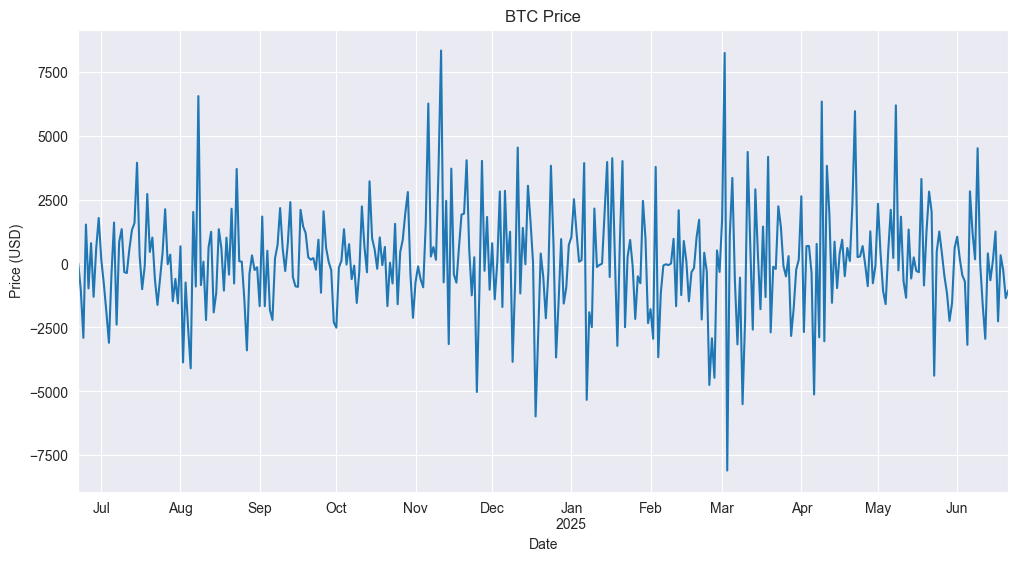

In [4]:
daily_data[RESPONSE].plot.line(title=f'{COIN} Price', figsize=(12, 6), ylabel='Price (USD)', xlabel='Date')

<Axes: ylabel='Frequency'>

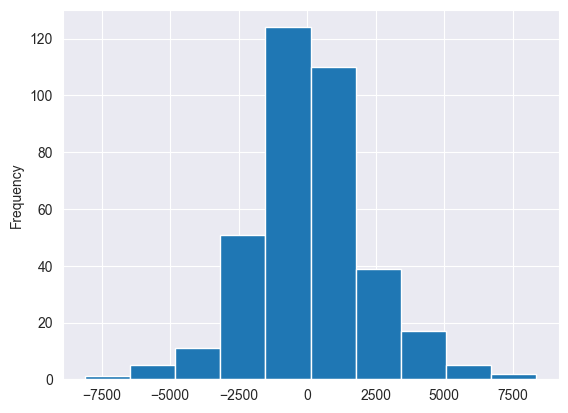

In [5]:
daily_data['gradient'].plot.hist()

In [7]:
daily_data[RESPONSE].describe()

count     365.000000
mean      104.212904
std      2108.934764
min     -8104.380000
25%      -973.030000
50%        37.970000
75%      1029.370000
max      8341.810000
Name: gradient, dtype: float64

# Load the Transformer Model

Sequence the data to make it predict the next price

## Preprocess the data


In [8]:
daily_data = transformerDataSetup(daily_data)
daily_data[['sequence', 'next']]

,sequence,next
time,,
2024-06-22,"[-99999999.0, -99999999.0, -99999999.0, -99999...",63171.43
2024-06-23,"[64235.01, -99999999.0, -99999999.0, -99999999...",60263.00
2024-06-24,"[64235.01, 63171.43, -99999999.0, -99999999.0,...",61789.71
2024-06-25,"[64235.01, 63171.43, 60263.0, -99999999.0, -99...",60816.68
2024-06-26,"[64235.01, 63171.43, 60263.0, 61789.71, -99999...",61615.39
...,...,...
2025-06-17,"[64235.01, 63171.43, 60263.0, 61789.71, 60816....",104915.60
2025-06-18,"[64235.01, 63171.43, 60263.0, 61789.71, 60816....",104671.90
2025-06-19,"[64235.01, 63171.43, 60263.0, 61789.71, 60816....",103317.80


## Load the Model

### Data Setup

In [9]:
from sklearn.preprocessing import StandardScaler
DAYS_TO_PREDICT = 7
X_train, X_test, y_train, y_test, _, _ = transformerXTrainYTrain(daily_data, testSize=len(daily_data)-DAYS_TO_PREDICT)
X_train_norm, X_test_norm, y_train_norm, y_test_norm, sequence_scaler, target_scaler = normalize(X_train, X_test, y_train, y_test)

In [10]:
model = torch.load(f'../models/{COIN}_model.pth')

In [18]:
# Create model with appropriate settings for Bitcoin prediction
model = BaseTransformer(
    d_model=128,
    num_heads=8,
    num_layers=4,
    learning_rate=1e-4,  # This is fine now with normalized data
    batch_size=32,
    dropout=0.1,
    mask_value=FILL
)
model.fit(X_train_norm, y_train_norm, epochs=30, validation_data=(X_test_norm, y_test_norm))
torch.save(model, f'../models/{COIN}_model.pth')

Data shapes - X: torch.Size([358, 365, 1]), y: torch.Size([358, 1])
DataFrame column: sequences
Sample sequence length: 365


Training Progress:   0%|          | 0/30 [00:07<?, ?it/s]


KeyboardInterrupt: 

In [19]:
predictions = model.predict(X_test_norm)
predictions = target_scaler.inverse_transform(predictions).reshape(-1)
predictions = pd.Series(predictions, index=y_test.index)
y_test_norm.index = X_test_norm.index

rmse = root_mean_squared_error(y_test, predictions)
print(f"Test RMSE: {rmse:.4f}")

Test RMSE: 4523.3074


<Axes: title={'center': 'Difference on Prediction and Actual'}, xlabel='time'>

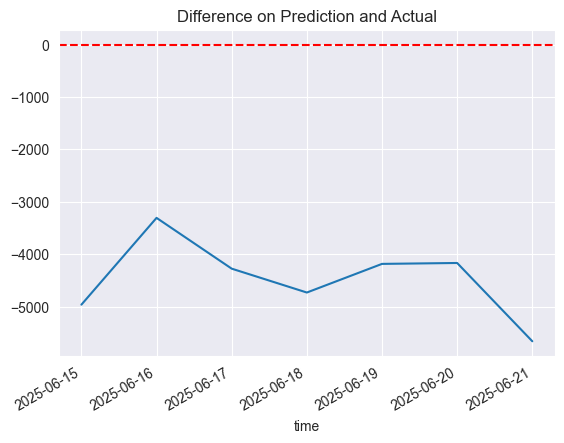

In [20]:
diff = predictions - y_test
plt.axhline(0.0, color='r', linestyle='--')
diff.plot.line(title='Difference on Prediction and Actual')

<Axes: title={'center': 'Predicted vs. Actual Value on Validation Month'}, xlabel='Date', ylabel='Price'>

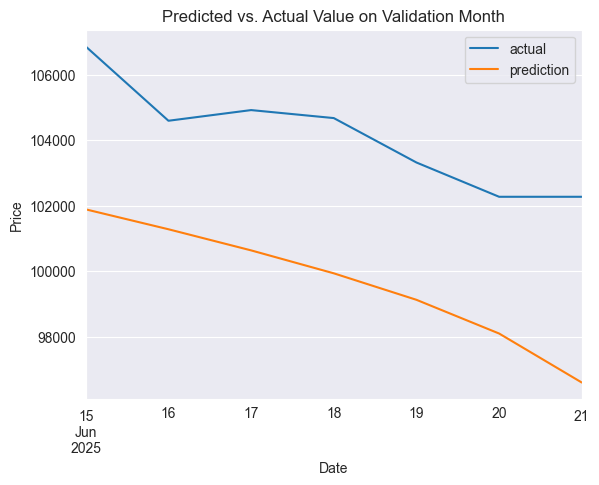

In [21]:
comparison = pd.concat([y_test, predictions], axis=1)
comparison.columns = ['actual', 'prediction']
comparison.plot.line(title='Predicted vs. Actual Value on Validation Month', xlabel='Date', ylabel='Price')

In [24]:
new = daily_data[RESPONSE].iloc[-30:]
new, next = sequence(new, len(new)-1)
new = pd.DataFrame({'sequences': [new]})
new = pd.DataFrame({""
        'sequences': normalize_sequences(new.iloc[:, 0], sequence_scaler)
    })
model.predict(new, sequence_scaler)[0, 0]

105260.125

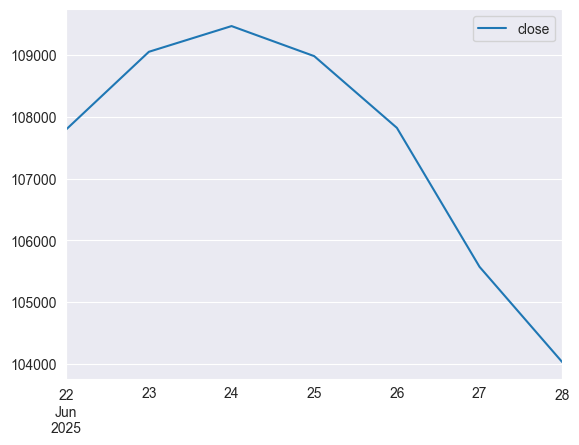

In [45]:
price = daily_data[RESPONSE].iloc[-1]
starter = daily_data[RESPONSE].iloc[-30:]
predictions = predict_sequence(model, price, starter, sequence_scaler, sequence_length=7)
new_days = pd.date_range(start=daily_data.index[-1] + pd.Timedelta(days=1), periods=len(predictions), freq='D')
predictions_df = pd.DataFrame(predictions, index=new_days, columns=[RESPONSE])
predictions_df.plot.line()
plt.show()

# Hyperparam Tuning